# 🗂️ NMF Topic Classifier
Classifies one or more files through a pre-trained NMF model in a single run.

**Usage:** Run all cells → enter file paths when prompted → see full output per file.

> **Pre-requisite:** Run `topic_modelling_best.ipynb` first and save:
> ```python
> import joblib
> joblib.dump(nmf_model,    'nmf_model.joblib')
> joblib.dump(tfidf_vec,    'tfidf_vectorizer.joblib')
> joblib.dump(shared_vocab, 'shared_vocab.joblib')
> ```

> **ℹ️ About scores:** NMF scores are reconstruction weights, not probabilities.
> Use **% Share** (shown in charts) — it's more intuitive for short documents.

In [24]:
!pip install scikit-learn nltk joblib wordcloud matplotlib seaborn -q



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Cell 2 — Imports & Config

In [25]:
import os, re, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import joblib

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

warnings.filterwarnings('ignore')
for c in ['punkt', 'stopwords', 'wordnet', 'punkt_tab']:
    nltk.download(c, quiet=True)
%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.family': 'sans-serif'})

MODEL_DIR = '.'   # folder containing the .joblib files

print('✅ Ready.')


✅ Ready.


---
## Cell 3 — Define Pipeline Functions

In [26]:
# ═══════════════════════════════════════════════════════════════════
#  FUNCTION 1: Preprocessing
# ═══════════════════════════════════════════════════════════════════
lemmatizer = WordNetLemmatizer()
STOP_WORDS  = set(stopwords.words('english'))
STOP_WORDS.update({
    'would','could','should','also','get','got','like','make','one','two',
    'three','many','much','said','say','know','think','use','used','using',
    'may','might','well','back','even','still','way','go','going','come',
    'came','take','good','people','time','year','new','old','thing','things',
    'article','writes','subject','document','edu','com','from',
})


def preprocess(text: str) -> str:
    """Full cleaning pipeline: HTML → noise → lowercase → lemmatise."""
    # HTML: kill <script> blocks, strip tags, decode entities
    text = re.sub(r'<script[^>]*>.*?</script>', ' ', text,
                  flags=re.DOTALL | re.IGNORECASE)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'&amp;|&lt;|&gt;|&quot;|&#\d+;|&nbsp;|&[a-z]+;', ' ', text)
    text = text.encode('ascii', 'ignore').decode('ascii')  # emojis
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # URLs
    text = re.sub(r'\S+@\S+', '', text)          # emails
    text = re.sub(r'\d+', '', text)               # digits
    text = re.sub(r'[^a-z\s]', ' ', text)         # punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [
        lemmatizer.lemmatize(t)
        for t in word_tokenize(text)
        if t not in STOP_WORDS and len(t) > 2
    ]
    return ' '.join(tokens)


# ═══════════════════════════════════════════════════════════════════
#  FUNCTION 2: Load Model
# ═══════════════════════════════════════════════════════════════════
def load_model(model_dir: str = '.'):
    """Load NMF model, TF-IDF vectoriser and shared vocabulary from disk."""
    nmf   = joblib.load(os.path.join(model_dir, 'nmf_model.joblib'))
    tfidf = joblib.load(os.path.join(model_dir, 'tfidf_vectorizer.joblib'))
    vocab = joblib.load(os.path.join(model_dir, 'shared_vocab.joblib'))
    top_words = [
        [vocab[i] for i in row.argsort()[::-1][:10]]
        for row in nmf.components_
    ]
    print(f'✅ Model loaded — {nmf.n_components} topics | vocab: {len(vocab):,}')
    return nmf, tfidf, vocab, top_words


# ═══════════════════════════════════════════════════════════════════
#  FUNCTION 3: Classify + Visualise (all-in-one)
# ═══════════════════════════════════════════════════════════════════
def run_pipeline(raw_text: str, file_label: str,
                 nmf_model, tfidf_vec, shared_vocab, nmf_top_words):
    """
    End-to-end pipeline for one document:
      preprocess → classify → print table → 6 visuals → summary card
    All output appears in this one function call / cell execution.
    """
    N_TOPICS   = nmf_model.n_components
    vocab_list = list(shared_vocab)

    # ── 1. Preprocess ─────────────────────────────────────────────────
    raw_tokens   = raw_text.split()
    cleaned      = preprocess(raw_text)
    clean_tokens = cleaned.split()

    print('\n' + '═'*65)
    print(f'  📄  FILE: {file_label}')
    print('═'*65)
    print(f'  Raw tokens   : {len(raw_tokens):,}')
    print(f'  Clean tokens : {len(clean_tokens):,}  '
          f'(↓{100*(1-len(clean_tokens)/max(len(raw_tokens),1)):.1f}% noise removed)')
    print(f'  Sample       : {" | ".join(clean_tokens[:15])} ...')

    if not clean_tokens:
        print('  ⚠  Empty after preprocessing — skipping.')
        return

    # ── 2. NMF classification ─────────────────────────────────────────
    vec        = tfidf_vec.transform([cleaned])
    topic_dist = nmf_model.transform(vec)[0]
    total      = topic_dist.sum() or 1e-9
    topic_pct  = 100 * topic_dist / total
    ranked     = topic_dist.argsort()[::-1]
    dom        = ranked[0]

    print(f'\n  {"Rank":<5} {"Topic":>6}  {"Raw Score":>10}  {"% Share":>8}  Top Words')
    print(f'  {"-"*65}')
    for r in range(N_TOPICS):
        t = ranked[r]
        if topic_dist[t] < 1e-5: break
        tag = '  ◀ DOMINANT' if r == 0 else ''
        print(f'  #{r+1:<4} Topic {t:2d}  {topic_dist[t]:10.5f}  '
              f'{topic_pct[t]:7.1f}%  ' + ' | '.join(nmf_top_words[t][:5]) + tag)

    print(f'\n  🏆 Dominant Topic {dom}: {" | ".join(nmf_top_words[dom][:6])}')
    print(f'     % Share  : {topic_pct[dom]:.1f}%')

    # ── 3. Active topics for charts ───────────────────────────────────
    active   = [(i, topic_dist[i], topic_pct[i])
                for i in range(N_TOPICS) if topic_dist[i] > 1e-5]
    active.sort(key=lambda x: x[1], reverse=True)
    a_idx    = [x[0] for x in active]
    a_raw    = [x[1] for x in active]
    a_pct    = [x[2] for x in active]
    a_labels = [f'T{i}\n{nmf_top_words[i][0]}' for i in a_idx]
    bar_col  = ['#E74C3C' if i == dom else '#3498DB' for i in a_idx]
    top8_idx = a_idx[:8]
    top8_pct = a_pct[:8]

    # ── VIS 1: Preprocessing + Raw/% bar ─────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(20, 4))

    # Before/after
    bars = axes[0].bar(['Raw', 'Clean'], [len(raw_tokens), len(clean_tokens)],
                       color=['#E74C3C','#2ECC71'], edgecolor='white', width=0.4)
    for bar, n in zip(bars, [len(raw_tokens), len(clean_tokens)]):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                     f'{n:,}', ha='center', fontweight='bold')
    axes[0].set_title('Raw vs Clean Token Count', fontweight='bold')
    axes[0].set_ylabel('Tokens')

    # Raw score bar
    b1 = axes[1].bar(a_labels, a_raw, color=bar_col, edgecolor='white', width=0.6)
    for bar, s in zip(b1, a_raw):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                     f'{s:.4f}', ha='center', va='bottom', fontsize=6, fontweight='bold')
    axes[1].set_title('NMF Raw Scores (red = dominant)', fontweight='bold')
    axes[1].set_ylabel('Raw Score'); axes[1].tick_params(axis='x', labelsize=7)

    # % share bar
    b2 = axes[2].bar(a_labels, a_pct, color=bar_col, edgecolor='white', width=0.6)
    for bar, p in zip(b2, a_pct):
        axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                     f'{p:.1f}%', ha='center', va='bottom', fontsize=6, fontweight='bold')
    axes[2].set_title('NMF % Share (more intuitive)', fontweight='bold')
    axes[2].set_ylabel('% Share'); axes[2].tick_params(axis='x', labelsize=7)

    plt.suptitle(f'Overview — {file_label}', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()
    # ── VIS 2: Pie + Radar ───────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Pie
    t8_labels = [f'T{i}: {nmf_top_words[i][0]}' for i in top8_idx]
    explode   = [0.09 if i == dom else 0 for i in top8_idx]
    pie_col   = plt.cm.Set3(np.linspace(0, 1, len(top8_idx)))
    _, texts, autotexts = axes[0].pie(
        top8_pct, labels=t8_labels, colors=pie_col,
        autopct='%1.1f%%', startangle=140, explode=explode,
        textprops={'fontsize': 8},
    )
    for at in autotexts: at.set_fontweight('bold')
    axes[0].set_title('Topic % Share — Top 8 (exploded = dominant)', fontweight='bold')

    # Radar
    N_R      = len(top8_idx)
    angles   = np.linspace(0, 2*np.pi, N_R, endpoint=False).tolist()
    vals     = top8_pct + [top8_pct[0]]
    ang_p    = angles + [angles[0]]
    ax_r     = plt.subplot(122, polar=True)
    ax_r.fill(ang_p, vals, color='#3498DB', alpha=0.25)
    ax_r.plot(ang_p, vals, color='#2C3E50', linewidth=2)
    ax_r.scatter(angles, top8_pct, color='#E74C3C', s=80, zorder=5)
    ax_r.set_xticks(angles)
    ax_r.set_xticklabels([f'T{i}\n{nmf_top_words[i][0]}' for i in top8_idx], fontsize=8)
    ax_r.set_title('Radar Chart — % Share', fontweight='bold', pad=20)

    plt.suptitle(f'Topic Distribution — {file_label}', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()
    
    # ── VIS 5: All-topics grid ───────────────────────────────────────
    cols  = 4
    rows  = (N_TOPICS + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows*3.2))
    axes = axes.flatten()
    for i in range(N_TOPICS):
        ws = nmf_top_words[i][:8]
        sc = sorted(nmf_model.components_[i], reverse=True)[:8]
        cl = '#E74C3C' if i == dom else '#3498DB'
        axes[i].barh(ws[::-1], sc[::-1], color=cl, edgecolor='white', alpha=0.85)
        pct_s = f'  ({topic_pct[i]:.1f}%)' if topic_dist[i] > 1e-5 else ''
        axes[i].set_title(
            f'Topic {i}{" ◀ dom" if i == dom else ""}{pct_s}',
            fontsize=8, fontweight='bold',
            color='#E74C3C' if i == dom else '#2C3E50'
        )
        axes[i].tick_params(labelsize=6)
        axes[i].set_xlabel('weight', fontsize=6)
    for j in range(N_TOPICS, len(axes)): axes[j].set_visible(False)
    plt.suptitle(f'All Topics — {file_label}  |  red = dominant',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()
    # ── Summary card ─────────────────────────────────────────────────
    summary = pd.DataFrame.from_dict({
        'File'               : file_label,
        'Raw Tokens'         : len(raw_tokens),
        'Clean Tokens'       : len(clean_tokens),
        'Active Topics'      : sum(1 for s in topic_dist if s > 1e-5),
        'Dominant Topic'     : dom,
        'Dominant % Share'   : f'{topic_pct[dom]:.1f}%',
        'Dominant Raw Score' : f'{topic_dist[dom]:.5f}',
        'Dominant Keywords'  : ' | '.join(nmf_top_words[dom][:5]),
        '#2 Topic'           : ranked[1],
        '#2 % Share'         : f'{topic_pct[ranked[1]]:.1f}%',
    }, orient='index', columns=['Value'])
    print('\n── Summary ──')
    from IPython.display import display
    display(summary)
print('✅ All functions defined.')


✅ All functions defined.


---
## Cell 4 — 🚀 Run the Pipeline

Enter **one or more file paths**, separated by commas or on separate lines.  
Press **Enter twice** when done.  
Each file is processed end-to-end: input stats → classification table → all visuals → summary card.

✅ Model loaded — 20 topics | vocab: 15,000

📂 Enter file path(s). Separate multiple files with commas, OR press Enter
   after each path and Enter twice to finish.


📋 Files to process: 1
   • nlp_preprocessing_2.txt

═════════════════════════════════════════════════════════════════
  📄  FILE: nlp_preprocessing_2.txt
═════════════════════════════════════════════════════════════════
  Raw tokens   : 689
  Clean tokens : 458  (↓33.5% noise removed)
  Sample       : ethic | digital | forensics | artificial | intelligence | redefined | boundary | digital | forensics | longer | simply | analyzing | evidence | understanding | pattern ...

  Rank   Topic   Raw Score   % Share  Top Words
  -----------------------------------------------------------------
  #1    Topic 19     0.02041     25.8%  space | orbit | shuttle | nasa | mission  ◀ DOMINANT
  #2    Topic 15     0.01946     24.6%  file | format | program | image | graphic
  #3    Topic  3     0.01136     14.4%  key | clipper | chip | encry

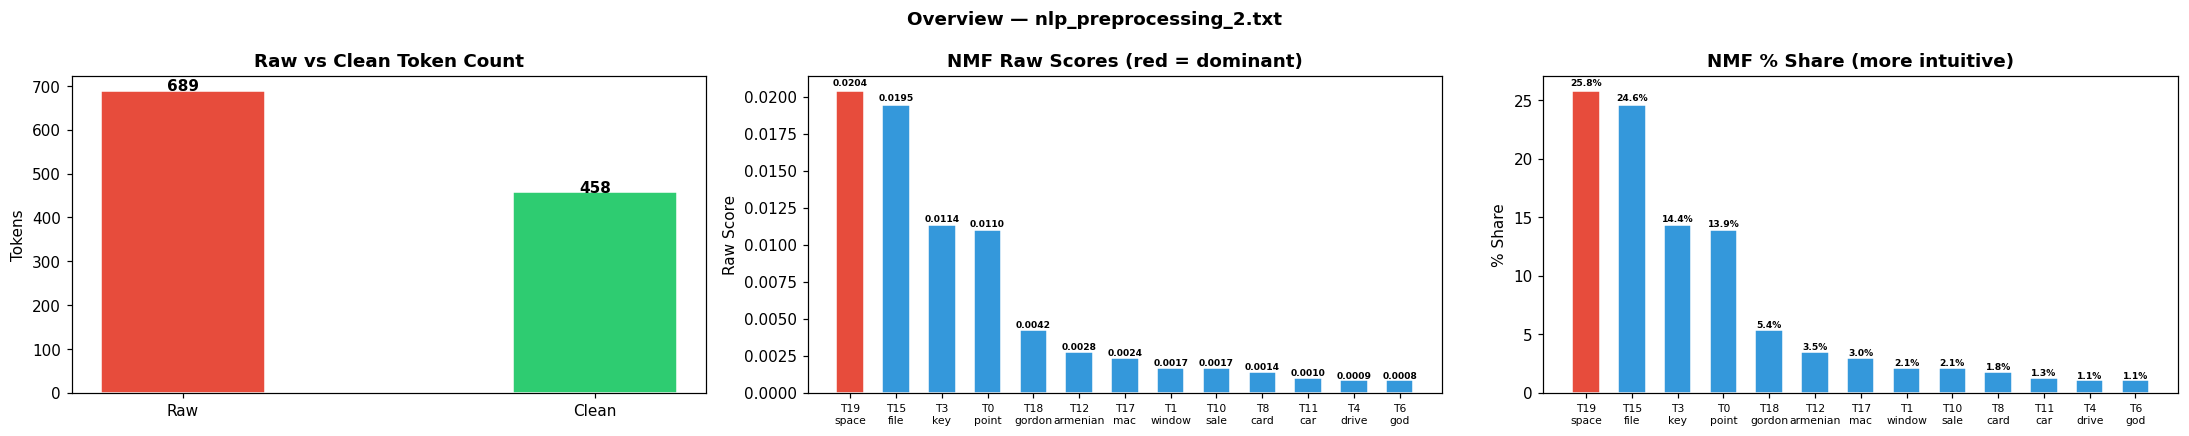

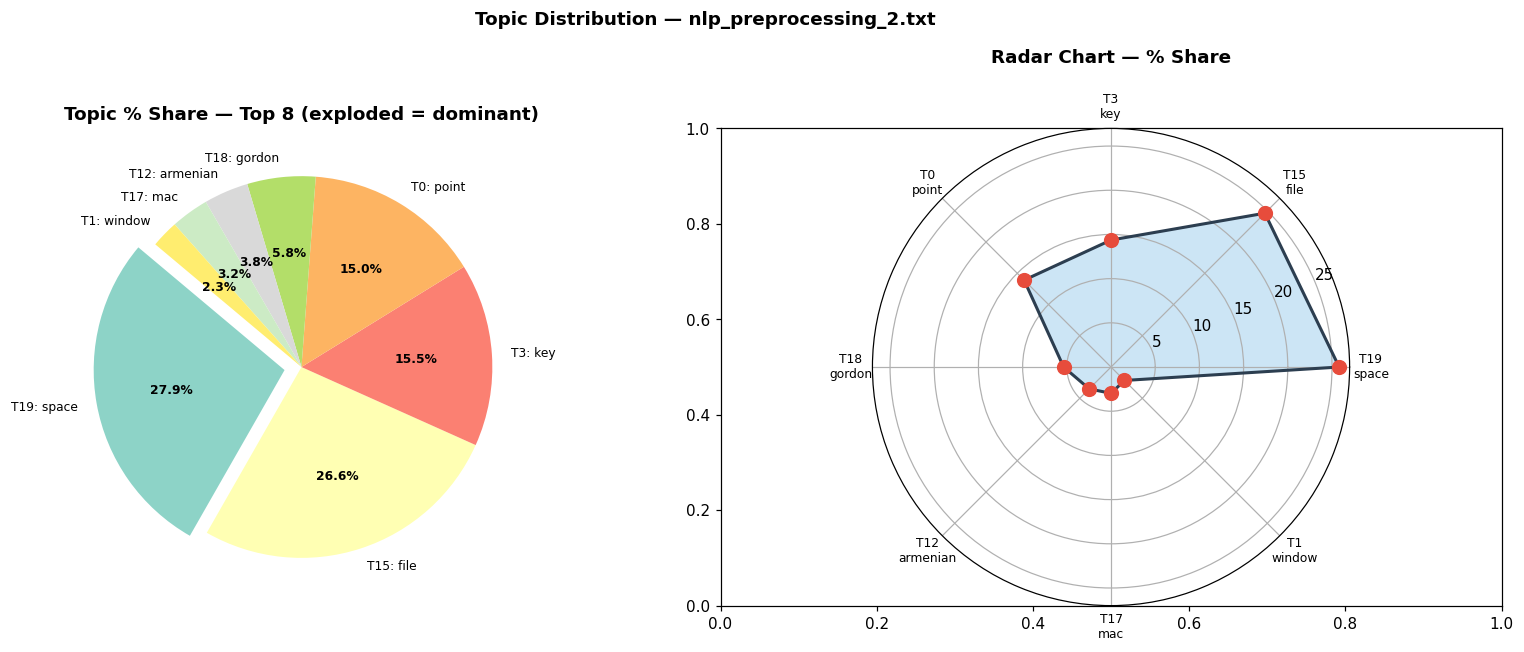

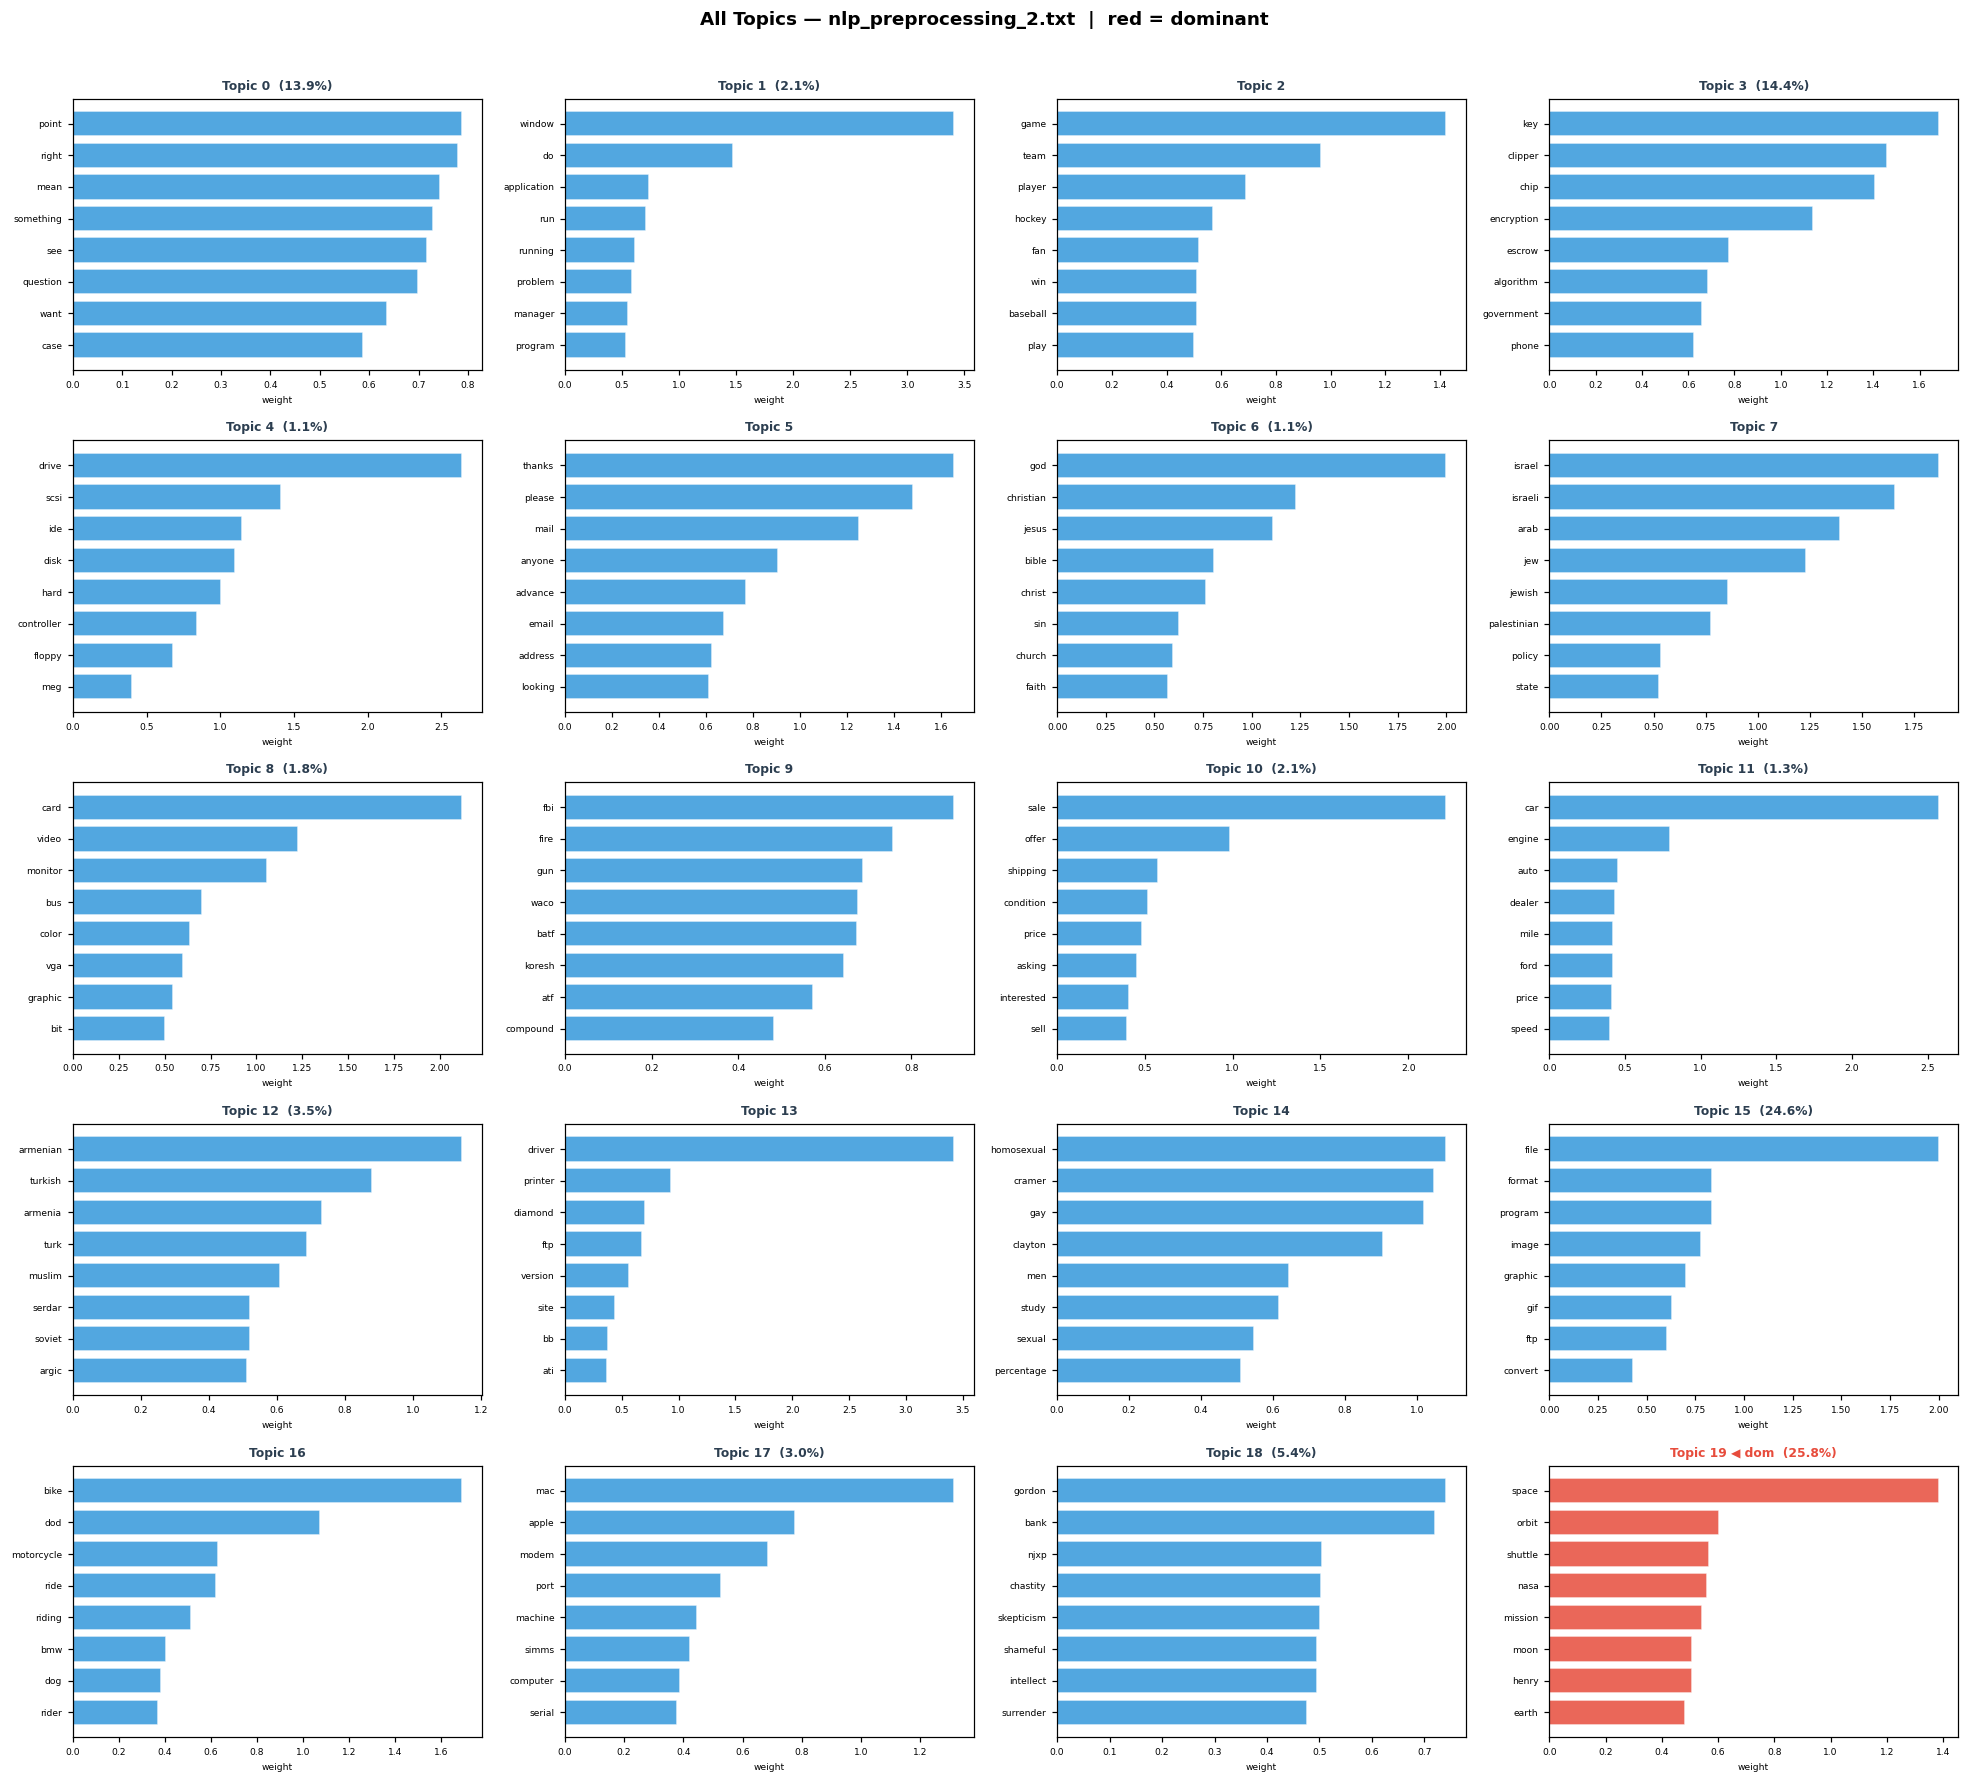


── Summary ──


,Value
File,nlp_preprocessing_2.txt
Raw Tokens,689
Clean Tokens,458
Active Topics,13
Dominant Topic,19
Dominant % Share,25.8%
Dominant Raw Score,0.02041
Dominant Keywords,space | orbit | shuttle | nasa | mission
#2 Topic,15
#2 % Share,24.6%



✅ All files processed.


In [28]:
# ── Load model (once) ─────────────────────────────────────────────────────────
nmf_model, tfidf_vec, shared_vocab, nmf_top_words = load_model(MODEL_DIR)

# ── Collect file paths from user ──────────────────────────────────────────────
print('\n📂 Enter file path(s). Separate multiple files with commas, OR press Enter')
print('   after each path and Enter twice to finish.\n')

lines, blank = [], 0
while blank < 1:
    line = input('Path: ').strip()
    if line == '':
        blank += 1
    else:
        blank = 0
        lines.append(line)

# Support comma-separated on a single line or one path per line
raw_paths = []
for line in lines:
    raw_paths.extend([p.strip() for p in line.split(',') if p.strip()])

file_paths = list(dict.fromkeys(raw_paths))   # deduplicate, preserve order
print(f'\n📋 Files to process: {len(file_paths)}')
for fp in file_paths:
    print(f'   • {fp}')

# ── Process each file ─────────────────────────────────────────────────────────
for fp in file_paths:
    if not os.path.exists(fp):
        print(f'\n❌ File not found: {fp} — skipping.')
        continue
    with open(fp, 'r', encoding='utf-8', errors='replace') as f:
        raw_text = f.read()
    run_pipeline(
        raw_text       = raw_text,
        file_label     = os.path.basename(fp),
        nmf_model      = nmf_model,
        tfidf_vec      = tfidf_vec,
        shared_vocab   = shared_vocab,
        nmf_top_words  = nmf_top_words,
    )

print('\n✅ All files processed.')
